In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

In [2]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [9]:

cosmo = cosmology.setCosmology('planck18')


box_length = 1000 #Mpc/h, quijote box side length

sim_cosmo = [0.3175, 0.049, 0.6711, 0.9624, 0.834]

params = {'flat': True, 'H0': 100 * sim_cosmo[2], 'Om0': sim_cosmo[0], 'Ob0': sim_cosmo[1], 'sigma8': sim_cosmo[4], 'ns': sim_cosmo[3]}

cosmo = cosmology.setCosmology('myCosmo', params)

# massbins
log_edges = np.array([[12, 12.01], [12.5, 12.6], [13, 13.1], [13.5, 13.6], [14.0, 14.2], [14.4, 14.7]])
massbins = 10**log_edges

cosmo_nums = np.array([0, 41, 53, 55, 66])

halo_path = f'/spiffball/edgarmsc/simulations/Quijote/Halos/Rockstar/fiducial_HR/0/hlist_4.hdf5' #testing on 0

hsb_path = f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/SBp/'

vel_path = f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/data/pairwise_velocity_selections/'

# # compile halo-halo pairs 
# halo_path = f'/spiff/hengweichang/AbacusSummit_base/snapshots/AbacusSummit_base_c000_ph000/halos/z0.200/halo_combined.h5'

# hsb_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/SBp/'

# vel_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairwise_velocity_selections/'

os.makedirs(os.path.dirname(hsb_path), exist_ok=True)
os.makedirs(os.path.dirname(vel_path), exist_ok=True)

vel_path = vel_path+'halo_halo_pairs_no_vlos_cut_massbin_test_SB250.hdf5'

# split into subboxes
with h5.File(halo_path, 'r') as hcat:

    #k = 3 # mass bin index for test
    hm_cut = hcat['Mvir'][()] >= 1e13 #& (m_p * hcat['N_total'][()] <= massbins[k][1])

    hpos = np.array([
        hcat['X'][()][hm_cut],
        hcat['Y'][()][hm_cut], 
        hcat['Z'][()][hm_cut],
    ]).T 

    hvel = np.array([
        hcat['VX'][()][hm_cut],
        hcat['VY'][()][hm_cut], 
        hcat['VZ'][()][hm_cut],
    ]).T

    hid = hcat['ID'][()][hm_cut]
    upid = hcat['PID'][()][hm_cut] 

    # generate_sub_box_ids(hpos%box_length, box_length, box_length / 4, hid.shape[0] // 1000, hsb_path, name='halo')

    # split_simulation_into_sub_boxes(
    #     positions=hpos%box_length, 
    #     velocities=hvel, 
    #     ids=hid, 
    #     upids=upid, 
    #     boxsize=box_length, 
    #     subsize=box_length / 4,
    #     chunksize=hid.shape[0] // 1000, 
    #     dtypes=[hpos[0].dtype, hvel[0].dtype], 
    #     path=hsb_path, 
    #     name='halo'
    # )

print('Starting pair selection for all mass bins...')
with h5.File(vel_path, 'w') as hdf:
    for k in range(len(massbins)):
    
        with h5.File(halo_path, 'r') as hcat:
            mcut = (hcat['Mvir'][()] >= massbins[k][0]) & (hcat['Mvir'][()] <= massbins[k][1]) # h^-1 M_sun

            hid = hcat['ID'][()][mcut]

            rel_r, rel_R, rel_rlos, vpeclos, rel_vr, rel_vt = get_pairwise_halo_pw_quants( len(hid), 
                                                                                                                        140, 
                                                                                                                        box_length, 
                                                                                                                        box_length / 4, 
                                                                                                                        halo_path, 
                                                                                                                        hsb_path, 
                                                                                                                        mass_mask=mcut,
                                                                                                                        pos_vel_labels=['X', 'Y', 'Z', 'VX', 'VY', 'VZ'],
                                                                                                                        id_label='ID',
                                                                                                                        vmax_label='Vmax',
                                                                                                                        Abacus =False,
                                                                                                                        n_jobs=84)  
            
            hdf.create_dataset(name=f'r/{k}', data=rel_r, dtype=np.float64) 
            hdf.create_dataset(name=f'R/{k}', data=rel_R, dtype=np.float64) 
            hdf.create_dataset(name=f'rlos/{k}', data=rel_rlos, dtype=np.float64) 
            hdf.create_dataset(name=f'vpeclos/{k}', data=vpeclos, dtype=np.float64) 
            hdf.create_dataset(name=f'vr/{k}', data=rel_vr, dtype=np.float64)
            hdf.create_dataset(name=f'vt/{k}', data=rel_vt, dtype=np.float64) 


Starting pair selection for all mass bins...
	● Elapsed time: 0:00:00.000018 get_pairwise_halo_pw_quants


Processing sub-box:   0%|                                                    | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

	● Elapsed time: 0:00:13.375888 get_pairwise_halo_pw_quants


  0%|          | 0/64 [00:00<?, ?it/s]

...

Processing sub-box:   0%|                                                    | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

	● Elapsed time: 0:00:23.842952 get_pairwise_halo_pw_quants


  0%|          | 0/64 [00:00<?, ?it/s]

	● Elapsed time: 0:00:07.754542 get_pairwise_halo_pw_quants


In [16]:
with h5.File(vel_path, 'r') as hdf:
    print(len(hdf['r/3'][()]))

280004525


In [17]:
4.5752492428470575 * 280004525

1281090491.0

In [13]:
print((rel_r == 0).sum(), len(rel_r))

4830 40581393


In [12]:
# define paths to selections, save

path = f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_massbin_test_SB250.hdf5' 
save_path = f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/data/' 

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dict, master_df = bin_pairwise_cat(path, save_path, R_bins=r_perp, rlos_bins=r_los, M_bins=massbins)


Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/fid_HR/0/data/binned_M5_1.00e+12-5.01e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5


Processing sub-box:   0%|                                                    | 0/64 [20:23<?, ?it/s]


In [14]:
pos, vel, hid_sb, _, _ = load_halos(sub_box_id=0, boxsize=box_length,
                                    subsize=box_length/4, path=hsb_path)
print(len(pos), pos.min(axis=0), pos.max(axis=0))

62080 [0.01113 0.01303 0.02984] [999.99866 999.98151 999.99689]


In [15]:
print(hm_cut.sum() / box_length**3)   # run for both sims

0.000486281


In [ ]:
# load saved binned data

cosmo_nums = np.array([0, 41, 53, 55, 66])

paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_3massbins_SB250.hdf5' for sim_num in cosmo_nums]
save_paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/{sim_num}/data/' for sim_num in cosmo_nums]

# bin selections

# mass bins
log_edges = np.array([[13.2, 13.3], [13.5, 13.7], [14.1, 14.7]])
massbins = 10**log_edges

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dicts = []
master_dfs = []

for p_i, path in enumerate(save_paths[:3]):
    binned_dict, master_df = load_pairwise_cat(path+'binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5')
    
    binned_dicts.append(binned_dict)
    master_dfs.append(master_df)

In [5]:
# compute mean radial velocity profiles <v_r|r, M> for each sim 

mean_vr_r_m = np.full((len(M_cens), len(r_p)), np.nan)
mean_vr_r_m_interps = np.empty((len(M_cens)), dtype=object)

data_df = master_df

data_df['r'] = np.sqrt(data_df['R']**2 + data_df['rlos']**2)
data_df['r_bin'] = pd.cut(data_df['r'], bins=r_perp, labels=False, include_lowest=True)

profile = (
    data_df.dropna(subset=['r_bin'])
    .groupby(['M_bin', 'r_bin'])['vr']
    .mean()
)

mean_vr_r_m = profile.unstack('r_bin').reindex(columns=range(len(r_p))).values

for k in range(mean_vr_r_m.shape[0]):
    y = mean_vr_r_m[k]
    mask = np.isfinite(y)
    if mask.sum() < 4:  # need enough points for k=5 spline; adjust threshold if needed
        mean_vr_r_m_interps[k] = None
        continue
    mean_vr_r_m_interps[k] = UnivariateSpline(r_p[mask], y[mask], s=0, k=5, ext=3)

In [6]:
redshift = 0.2
a = 1/(1+redshift)

conv = a*cosmo.Hz(redshift)/cosmo.h * box_length
conv

np.float64(184585.0385567896)

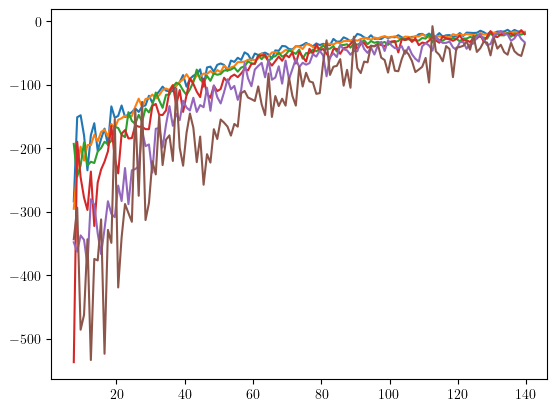

In [8]:
for k in range(len(M_cens)):    
    plt.plot(r_p, conv*mean_vr_r_m[k])

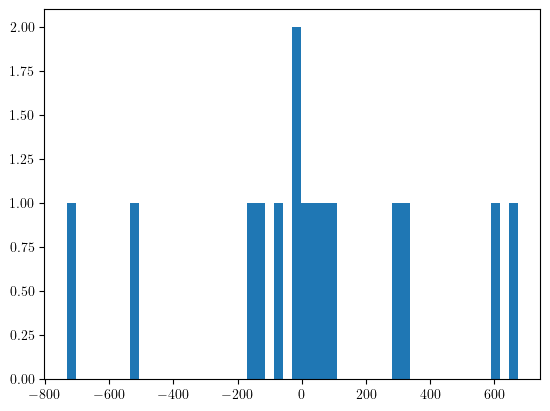

In [38]:
th = plt.hist(conv*binned_dict[0][0][100]['vpeclos'], bins=50)

In [9]:
# save 
os.makedirs(os.path.dirname('/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/'), exist_ok=True)
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/mean_vr_r_m_sims.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('mean_vr_r_m_sims', data=mean_vr_r_m_sims)
    #hdf.create_dataset('interps', data=mean_vr_r_m_sims_interps) 

    hdf.attrs['r_edges'] = r_perp
    hdf.attrs['M_edges'] = massbins

In [12]:
# fit skew-t to P(v_pec|R, rlos, M) to each sim

from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)

data_dict = binned_dict
for k in range(len(M_cens)):
    if k not in data_dict:
        continue  # empty mass bin — leave as nan

    mean_vr_interp = mean_vr_r_m_interps[k]

    for j in range(len(r_p)):
        if j not in data_dict[k]:
            continue

        for i in range(len(r_l)):
            if i not in data_dict[k][j]:
                continue

            r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
            theta = np.arctan2(r_l[i], r_p[j])
            sin = np.sin(theta)

            peak = mean_vr_interp(r_3d) * sin

            width = np.std(data_dict[k][j][i]['vpeclos'])

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)
            cent = 0.5*(edges[1:] + edges[:-1])

            if np.isnan(hist).any():
                continue

            try:
                p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            
            ST_pars[k, j, i] = p
            ST_errs[k, j, i] = np.sqrt(np.diag(c))
            

In [14]:
ST_pars[0, 0, 0]

array([-0.00078733,  0.00160203, -0.1       ])

In [12]:
# parallel version
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm import tqdm
from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(cosmo_nums), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)


def fit_sim_k(sim, k, data_dict, mean_vr_interp, r_p, r_l, nus):
    out = {}
    for j in range(len(r_p)):
        if j not in data_dict[k]:
            continue
        for i in range(len(r_l)):
            if i not in data_dict[k][j]:
                continue
            r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
            theta = np.arctan2(r_l[i], r_p[j])
            peak = mean_vr_interp(r_3d) * np.sin(theta)
            width = np.std(data_dict[k][j][i]['vpeclos'])

            ve = np.linspace(peak-2500, peak+2500, 51)
            vc = 0.5*(ve[1:] + ve[:-1])
            hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)

            if np.isnan(hist).any():
                continue
            try:
                p, c = curve_fit(
                    lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                    vc, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            out[(j, i)] = (p, np.sqrt(np.diag(c)))
    return sim, k, out

tasks = [(sim, k) for sim in range(len(cosmo_nums))
         for k in range(len(M_cens)) if k in binned_dicts[sim]]

with tqdm_joblib(tqdm(total=len(tasks), desc="Fitting skew-T")):
    results = Parallel(n_jobs=-1)(
        delayed(fit_sim_k)(sim, k, binned_dicts[sim], mean_vr_r_m_sims_interps[sim][k], r_p, r_l, nus)
        for sim, k in tasks
    )

for sim, k, out in results:
    for (j, i), (p, err) in out.items():
        ST_pars[sim, k, j, i] = p
        ST_errs[sim, k, j, i] = err

  0%|          | 0/15 [00:00<?, ?it/s]

Fitting skew-T:   0%|          | 0/15 [12:04<?, ?it/s]


In [70]:
# save 
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/ST_pars_nu6_meas_sigv.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('STpars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)
    hdf.create_dataset('meas_sigv', data=meas_sigv)

    hdf.attrs['rperp_edges'] = r_perp
    hdf.attrs['rlos_edges'] = r_los
    hdf.attrs['M_edges'] = massbins
    hdf.attrs['nu'] = nus
    hdf.attrs['sim_sums'] = cosmo_nums 

In [15]:
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

In [68]:
meas_sigv.shape

(5, 3, 135, 135)

In [69]:
ST_pars.shape

(5, 3, 135, 135, 3)

In [18]:
# measure widths
meas_sigv = np.full((len(M_cens), len(r_p), len(r_l)), np.nan)


for k in range(len(M_cens)):

    if k not in data_dict:
        continue  # empty mass bin — leave as nan

    for j in range(len(r_p)):
        if j not in data_dict[k]:
            continue

        for i in range(len(r_l)):
            if i not in data_dict[k][j]:
                continue
            
            std = np.std(data_dict[k][j][i]['vpeclos'])

            meas_sigv[k, j, i] = std

In [19]:
# compute 1-D isotropic halo velocity dispersion for halos in sims. How different from one another, MDPL2?

# non-linear Pk instead 
import camb
from camb import model

camb_params = [cosmo.H0, cosmo.Ombh2, cosmo.Omh2 - cosmo.Ombh2, cosmo.ns]

def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):

    pars = camb.set_params(H0=params[0], ombh2=params[1], omch2=params[2], ns=params[3])
    pars.set_matter_power(redshifts=[redshift], kmax=10.0) 
    pars.NonLinear = model.NonLinear_both

    results = camb.get_results(pars)
    kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
        minkh=1e-4, maxkh=5.0, npoints=500
    )
    pk_nl = pk_nl[0] 

    h = params[0] / 100.0

    Om0 = (params[1] + params[2]) / h**2
    Omz = Om0 * (1.0 + redshift)**3 / (params[0] / (100.0 * h))**2
    f = Omz**0.55 # growth rate

    a = 1/(1+redshift)
    conv = a * params[0] / h

    sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
    sigma0_nl = np.sqrt(sigma0_nl_sq)

    return sigma0_nl

    
sigma = get_sigma0_nl(camb_params, 0.0)
print(sigma)


352.18191850987677


In [21]:
np.isnan(ST_pars[:, :, :, 2]).sum()/len(ST_pars[:, :, :, 2].flatten())

np.float64(0.013141289437585734)

In [22]:
meas_sigv.shape

(6, 135, 135)

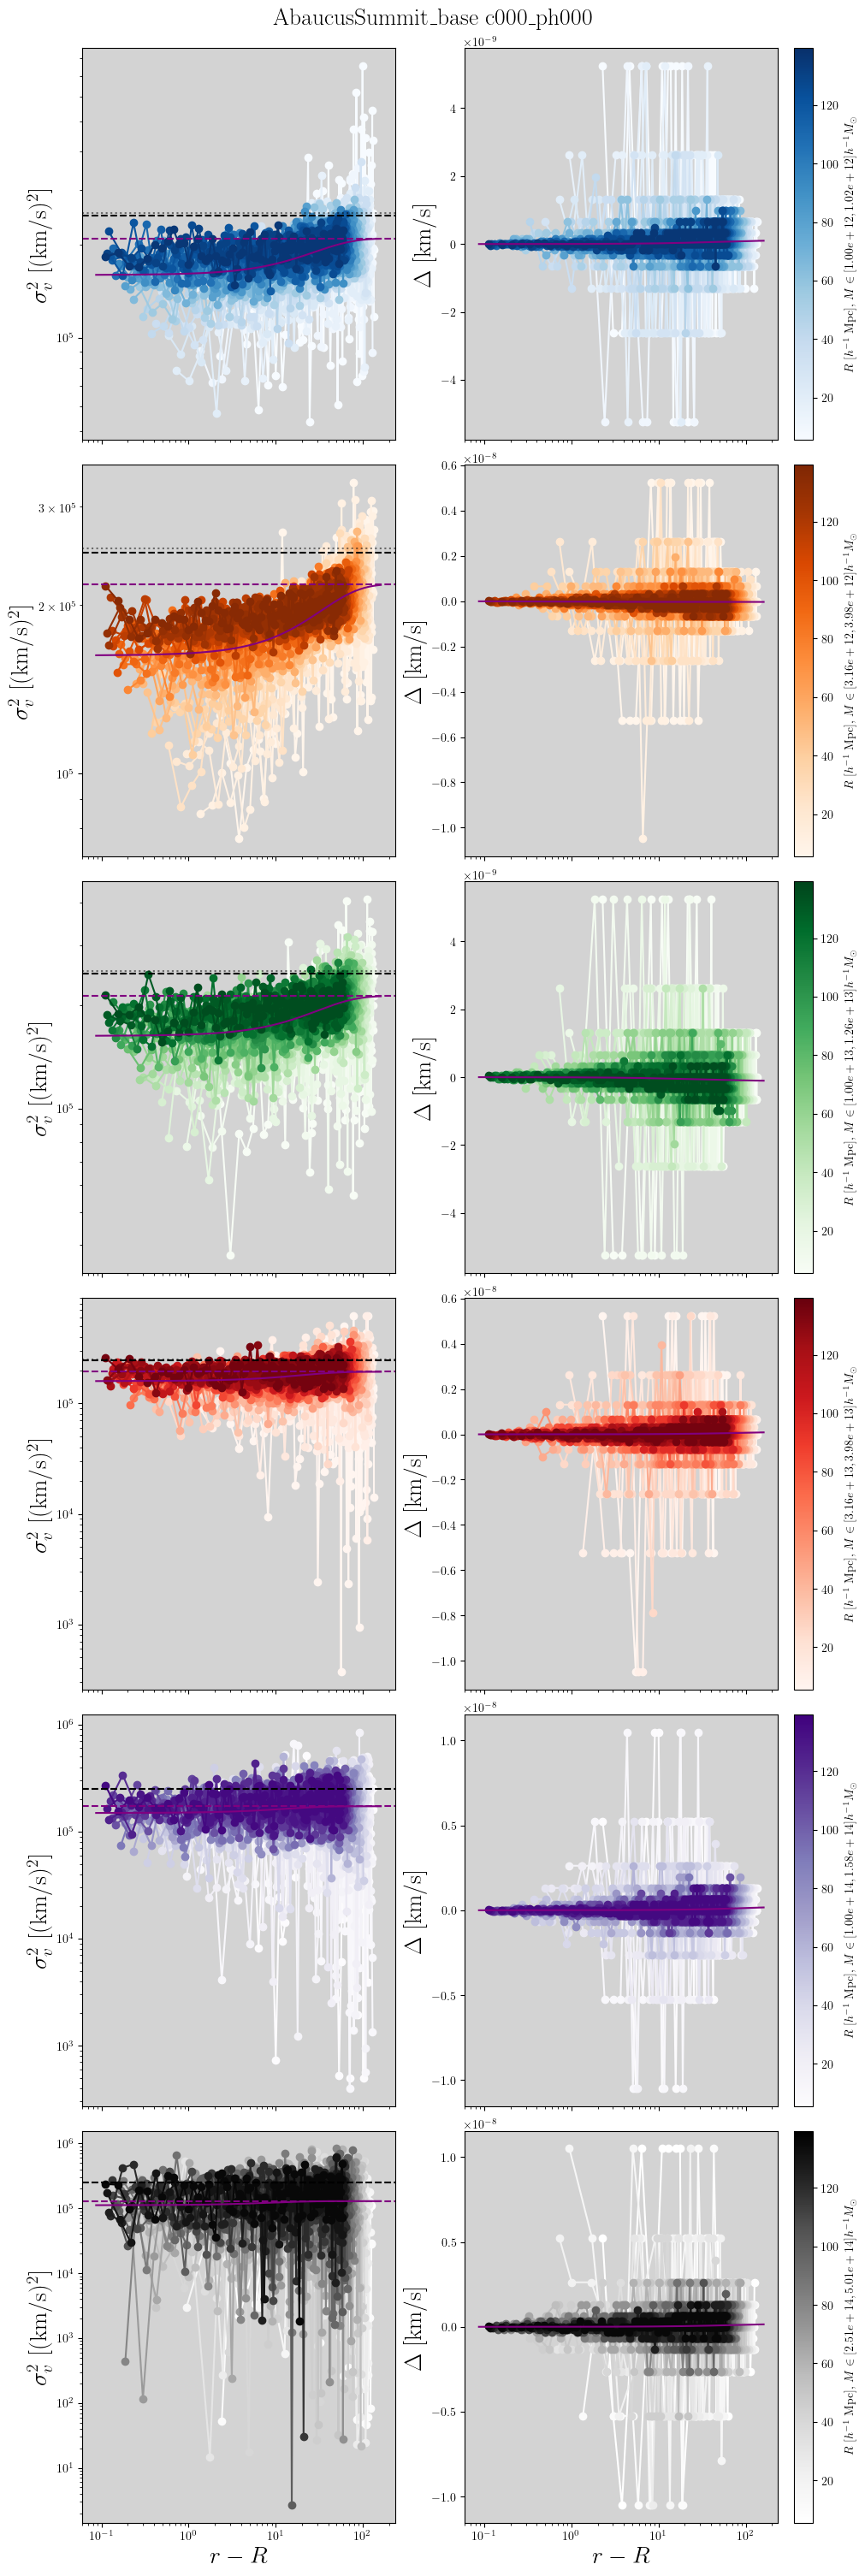

In [28]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((len(M_cens), 3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((len(M_cens), 2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(M_cens), len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[:, -1]


fig, ax = plt.subplots(len(M_cens), 2, figsize=(10, 5*len(M_cens)), layout='constrained', sharex=True)

fig.suptitle(rf"AbaucusSummit_base c000_ph000", fontsize=20)

for k in range(len(M_cens)):

    mean_vr_interp = mean_vr_r_m_interps[k]

    Delta = conv*ST_pars[k, :, :, 0] - conv*mean_vr_interp(r) * r_l / r
    com_inputs = [(conv*meas_sigv[k])**2, conv*Delta]

    smask = np.isfinite((conv*meas_sigv[k]).flatten()) & ((conv*meas_sigv[k]).flatten() > 0.1)
    dmask = np.isfinite(conv*Delta.flatten()) & (conv*Delta.flatten() > -1000)

    # fit models to each input 

    popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], ((conv*meas_sigv[k])).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
    popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], conv*Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

    sig_opts[k] = popt_sig
    sig_errs[k] = np.sqrt(np.diag(sig_cov))
    del_opts[k] = popt_del 
    del_errs[k] = np.sqrt(np.diag(del_cov))


    xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

    for j in range(0, len(r_p), skip):
        for i in range(2):

            y = com_inputs[i][j, :]
            
            if i == 0:
                mask = y > 0.1

                # if j == 0:
                #     popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[k, 0], A, s), x2[:, j], conv*meas_sigv[k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                #     A_rho_R[k, j//skip], sig_rho_fix = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov[0, 0])

                #     ax[k, i].plot(xs, sigma_mod(xs, sig_opts[k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                # else:
                #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[k, 0], A, sig_rho_fix), x2[:, j], conv*meas_sigv[k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                #     A_rho_R[k, j//skip] = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov)

                #     ax[k, i].plot(xs, sigma_mod(xs, sig_opts[k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

            if i == 1:
                mask = y > -1000

            ax[k, i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[k][j])

            ax[k, i].set_facecolor('lightgray')
            
            ax[k, i].set_ylabel(names[i], fontsize=20)
            
            ax[k, i].set_xscale('log')
            
    norm = Normalize(vmin=min(r_p), vmax=max(r_p))
    sm = ScalarMappable(norm=norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax[k, -1])
    cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

    ax[k, 0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
    #ax[k, 0].set_ylim((140_000, 300_000))
    ax[k, 0].set_xscale('log')
    ax[k, 0].axhline(2*(sigma)**2, c='k', ls='--')
    ax[k, 0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
    ax[k, 0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
    ax[k, 0].set_yscale('log')

    ax[-1, 0].set_xlabel(r'$r-R$', fontsize=20)
    ax[-1, 1].set_xlabel(r'$r-R$', fontsize=20)

    ax[k, 1].plot(xs, delta_mod(xs, *popt_del), c='purple')
    #ax[k, 1].set_ylim((-500, 450))

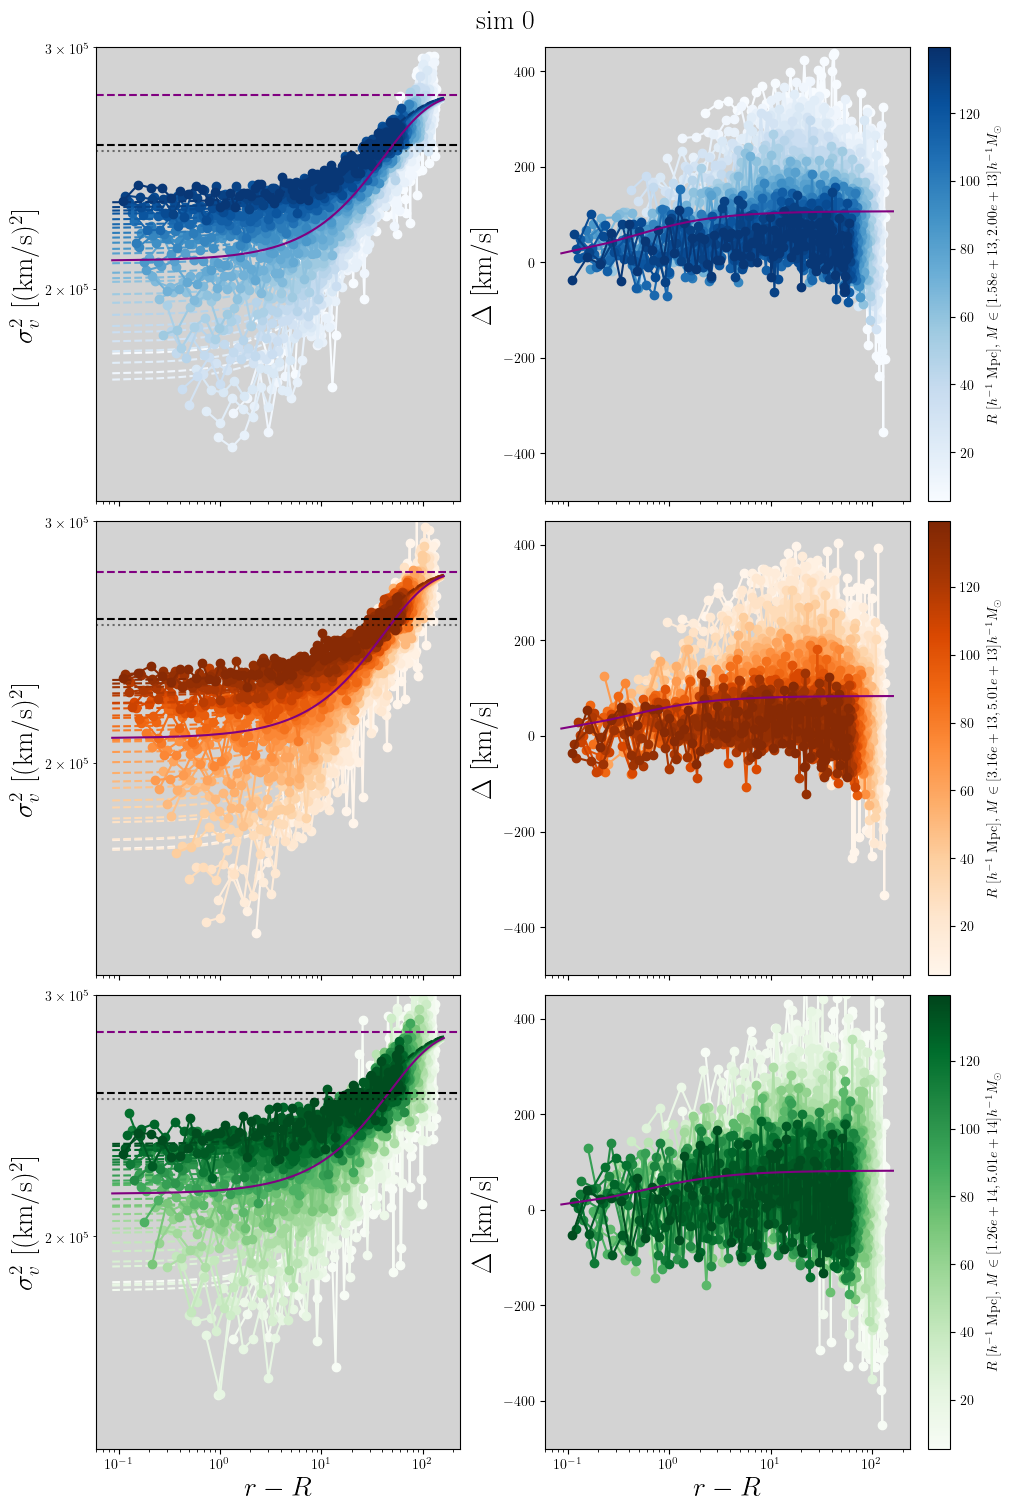

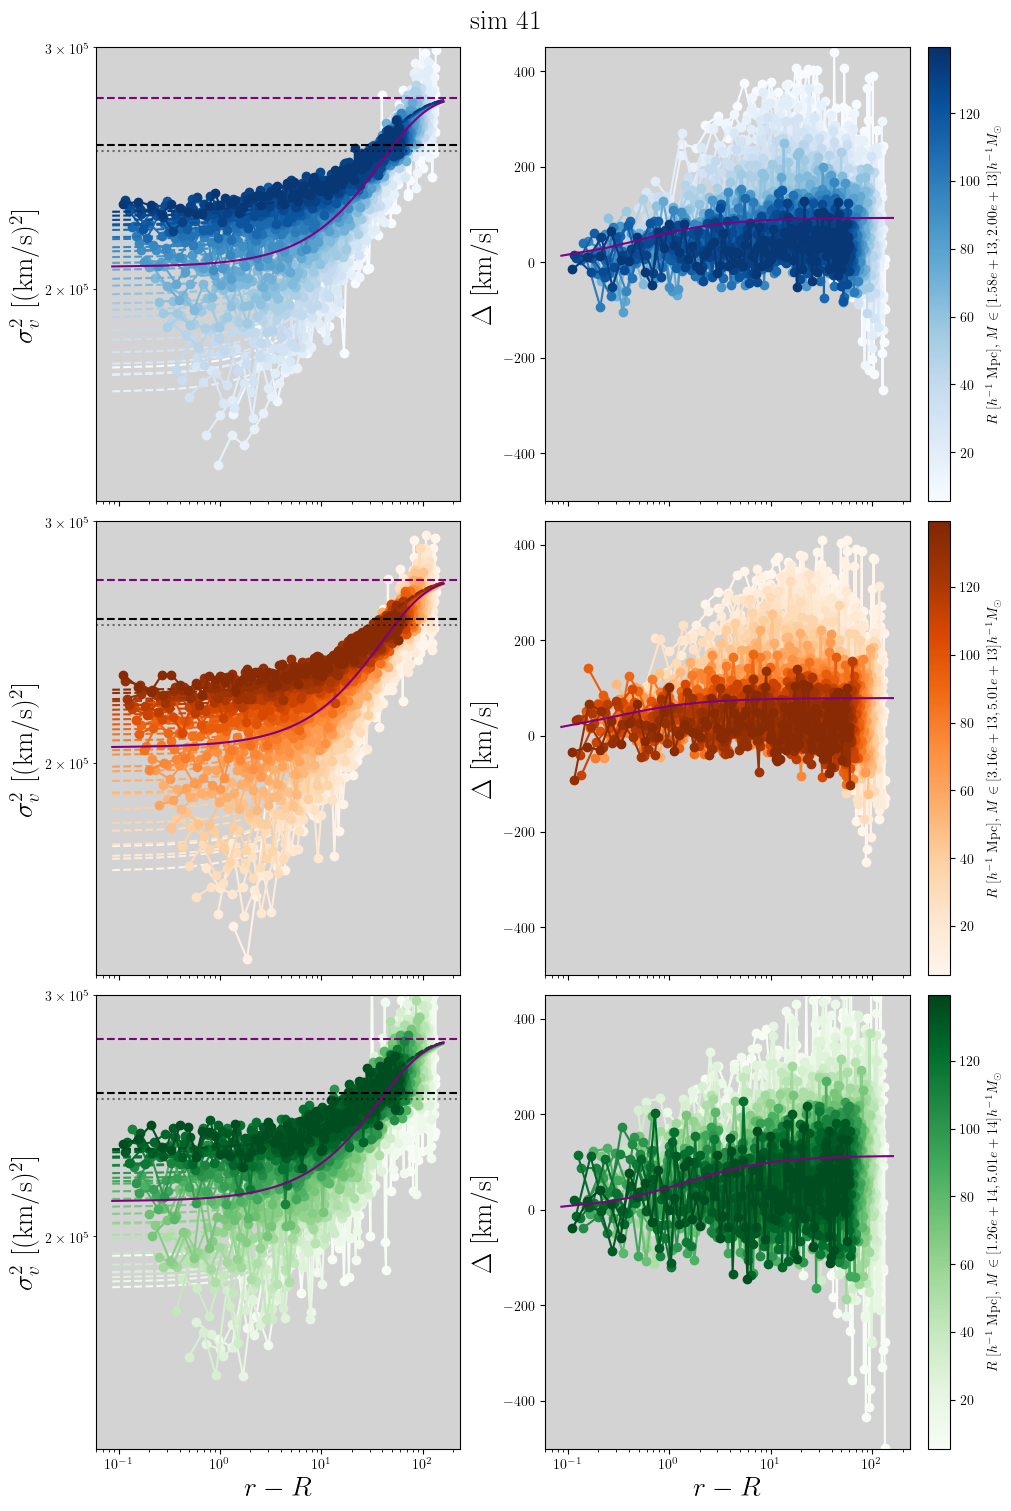

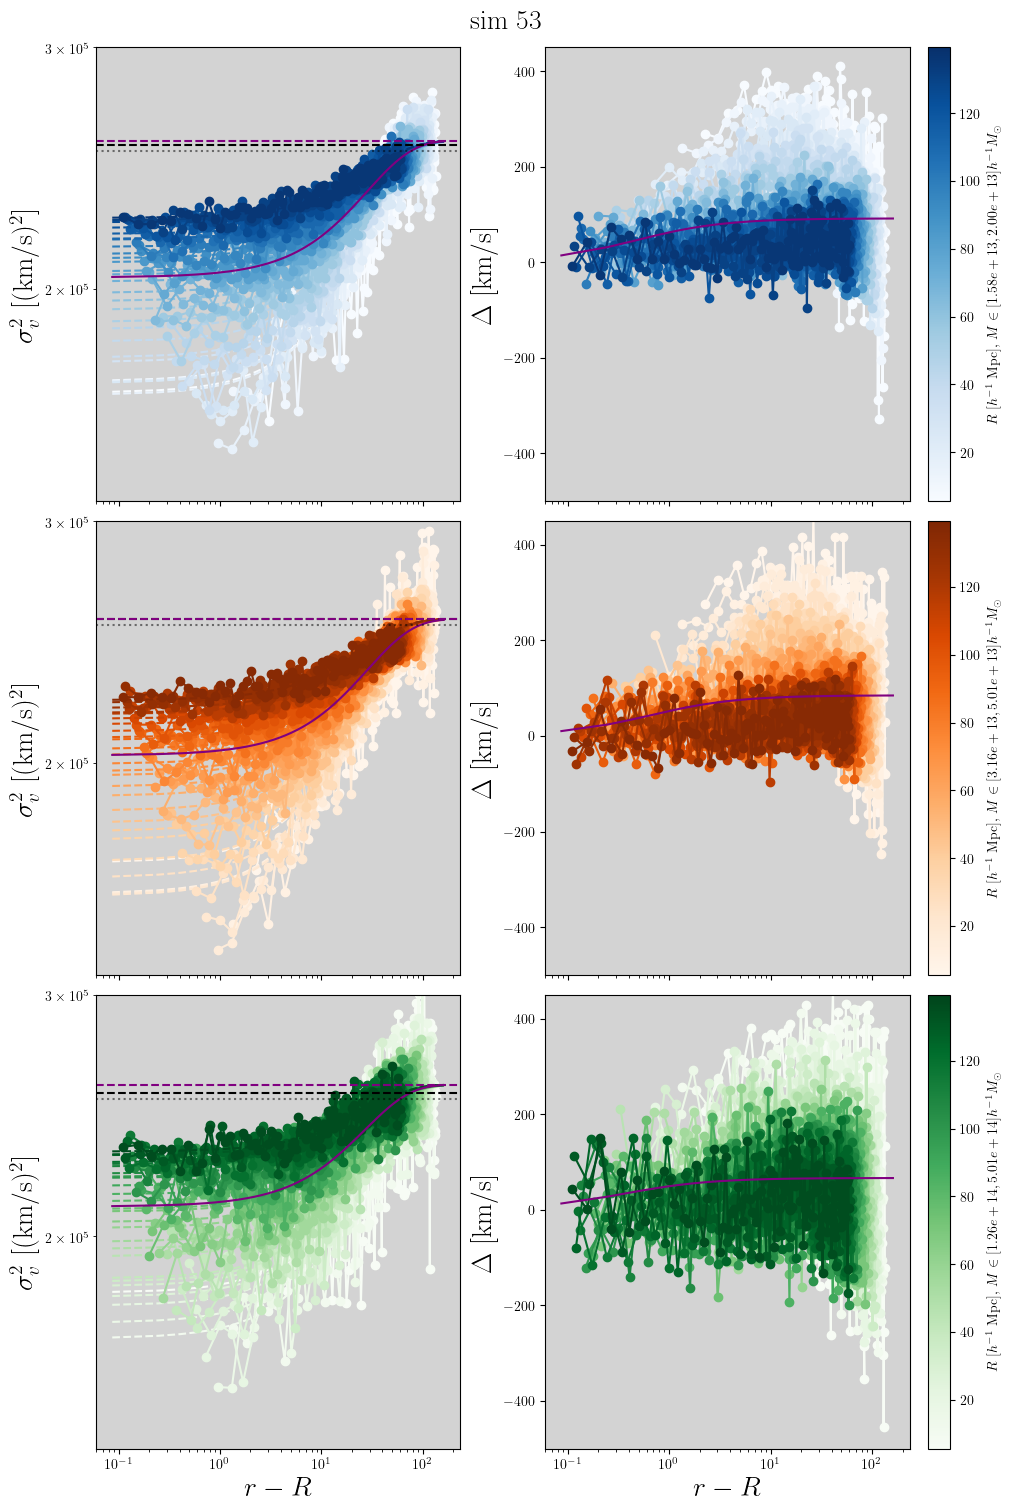

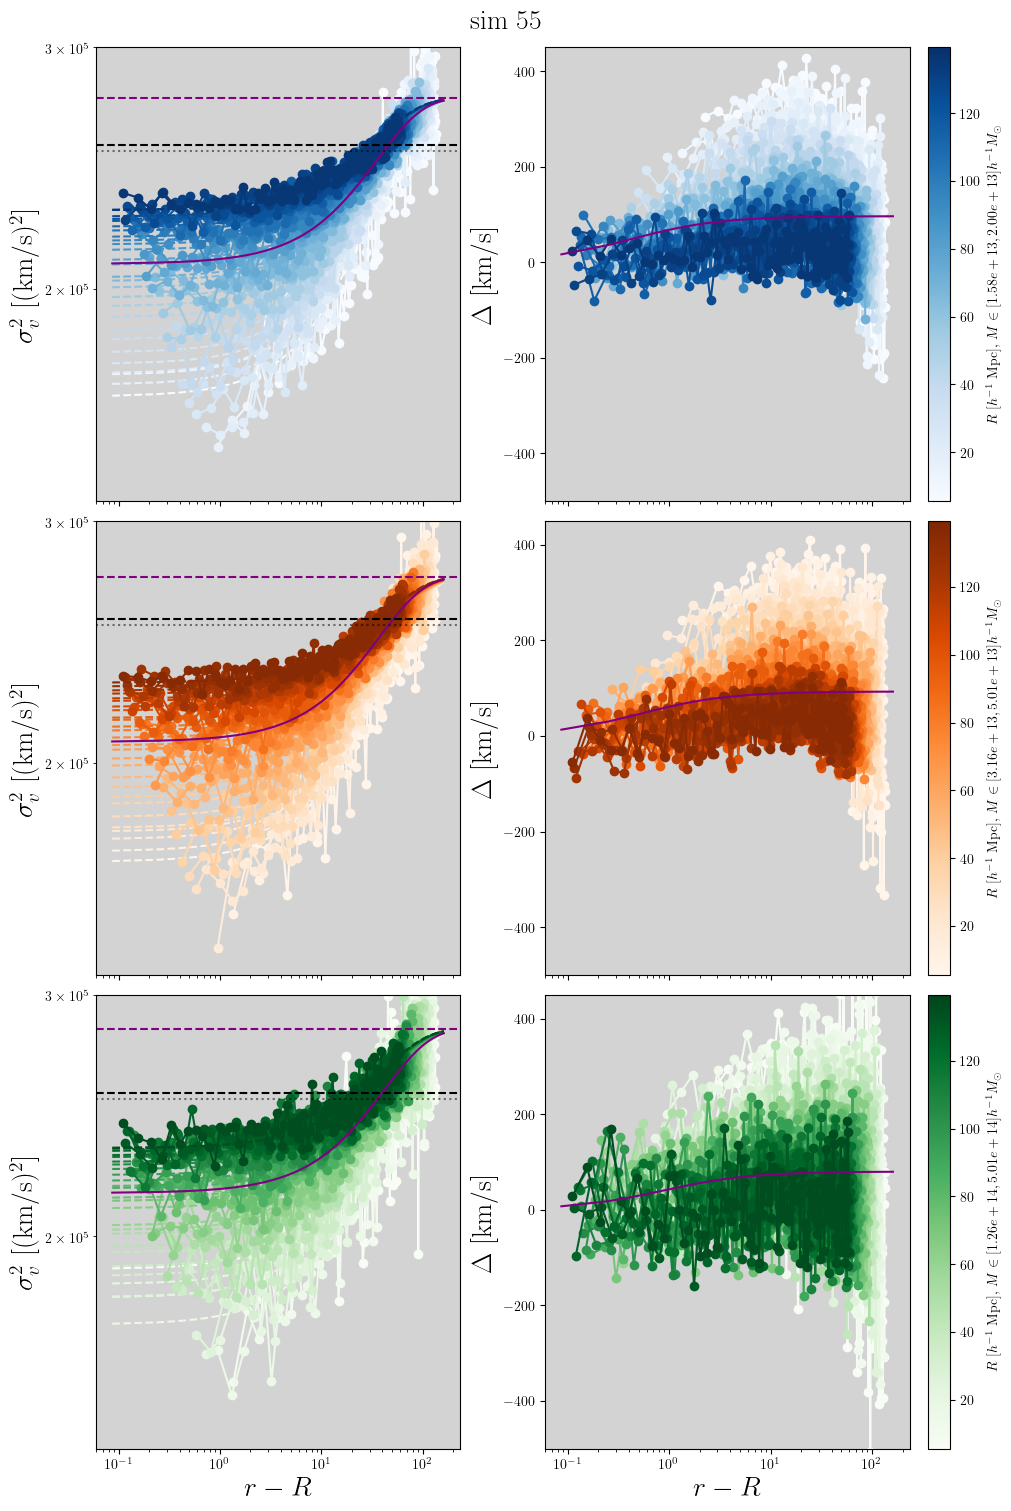

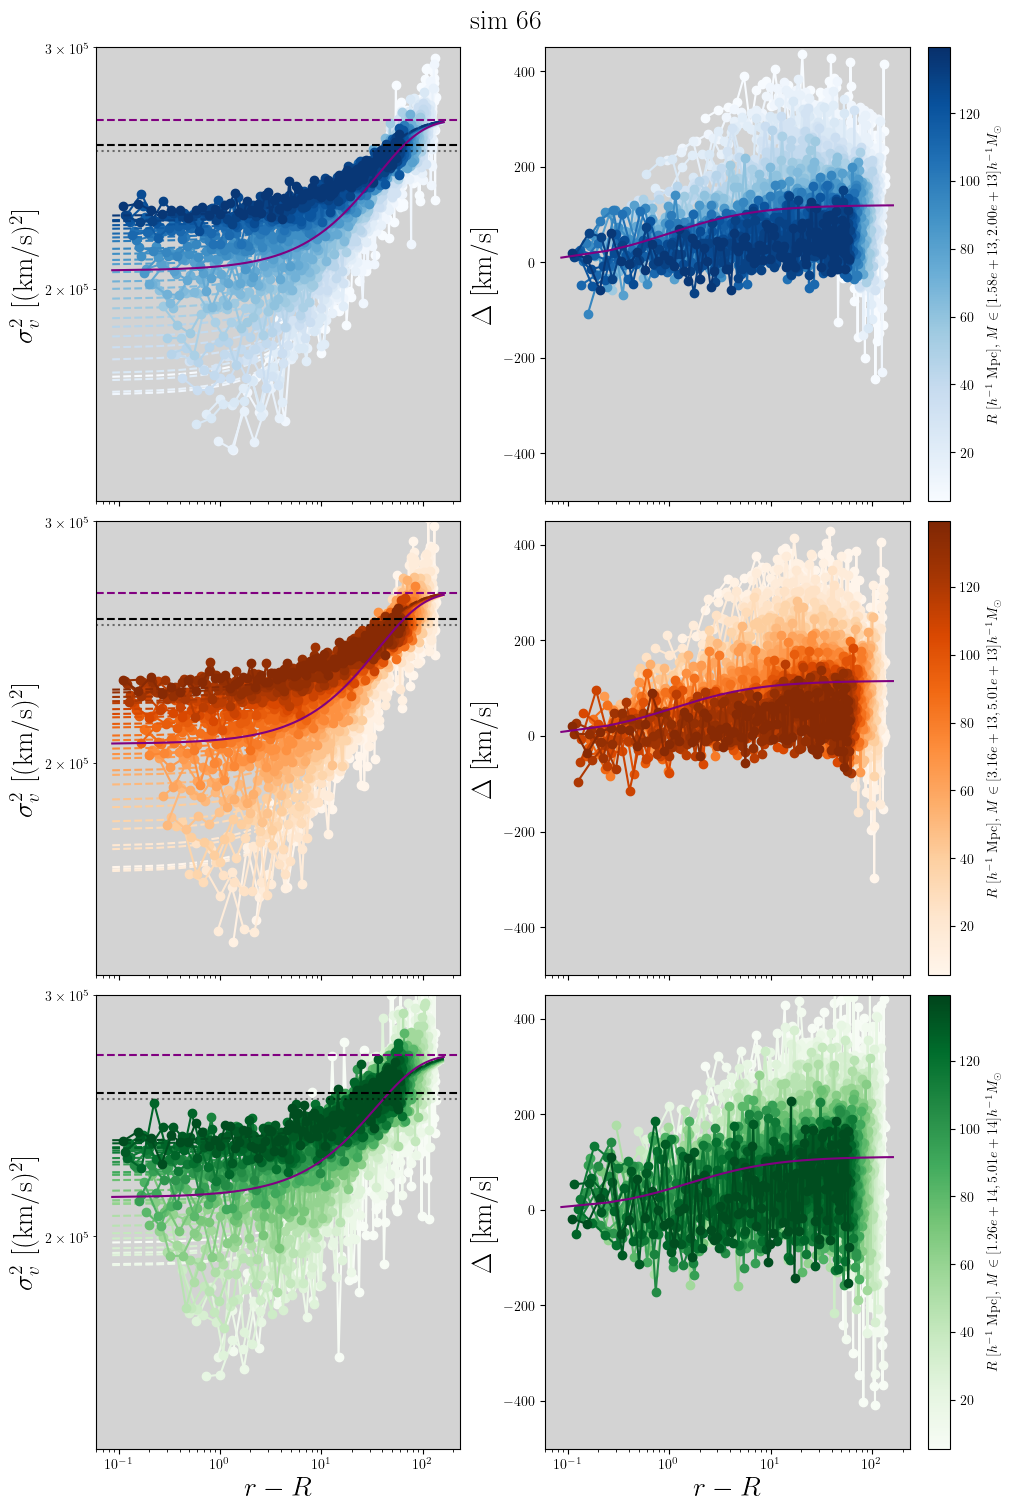

In [ ]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((len(cosmo_nums), len(M_cens), 3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((len(cosmo_nums), len(M_cens), 2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(cosmo_nums), len(M_cens), len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[:, :, -1]


for sim in range(len(cosmo_nums)):
    fig, ax = plt.subplots(len(M_cens), 2, figsize=(10, 5*len(M_cens)), layout='constrained', sharex=True)

    fig.suptitle(rf"sim {cosmo_nums[sim]}", fontsize=20)

    for k in range(len(M_cens)):

        mean_vr_interp = mean_vr_r_m_interps[sim][k]

        Delta = ST_pars[sim, k, :, :, 0] - mean_vr_interp(r) * r_l / r
        com_inputs = [meas_sigv[sim, k]**2, Delta]

        smask = np.isfinite(meas_sigv[sim, k].flatten()) & (meas_sigv[sim, k].flatten() > 0.1)
        dmask = np.isfinite(Delta.flatten()) & (Delta.flatten() > -1000)

        # fit models to each input 

        popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], (meas_sigv[sim, k]).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
        popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

        sig_opts[sim, k] = popt_sig
        sig_errs[sim, k] = np.sqrt(np.diag(sig_cov))
        del_opts[sim, k] = popt_del 
        del_errs[sim, k] = np.sqrt(np.diag(del_cov))


        xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

        for j in range(0, len(r_p), skip):
            for i in range(2):

                y = com_inputs[i][j, :]
                
                if i == 0:
                    mask = y > 0.1

                    if j == 0:
                        popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[sim, k, 0], A, s), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                        A_rho_R[sim, k, j//skip], sig_rho_fix = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov[0, 0])

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                    else:
                        popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[sim, k, 0], A, sig_rho_fix), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                        A_rho_R[sim, k, j//skip] = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov)

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

                if i == 1:
                    mask = y > -1000

                ax[k, i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[k][j])

                ax[k, i].set_facecolor('lightgray')
                
                ax[k, i].set_ylabel(names[i], fontsize=20)
                
                ax[k, i].set_xscale('log')
                
        norm = Normalize(vmin=min(r_p), vmax=max(r_p))
        sm = ScalarMappable(norm=norm, cmap=colormap_list[k])
        sm.set_array([])  # dummy array
        cbar = fig.colorbar(sm, ax=ax[k, -1])
        cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

        ax[k, 0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
        ax[k, 0].set_ylim((140_000, 300_000))
        ax[k, 0].set_xscale('log')
        ax[k, 0].axhline(2*(sigma)**2, c='k', ls='--')
        ax[k, 0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
        ax[k, 0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set_yscale('log')

        ax[-1, 0].set_xlabel(r'$r-R$', fontsize=20)
        ax[-1, 1].set_xlabel(r'$r-R$', fontsize=20)

        ax[k, 1].plot(xs, delta_mod(xs, *popt_del), c='purple')
        ax[k, 1].set_ylim((-500, 450))

In [27]:
del_opts.shape

(5, 3, 2)

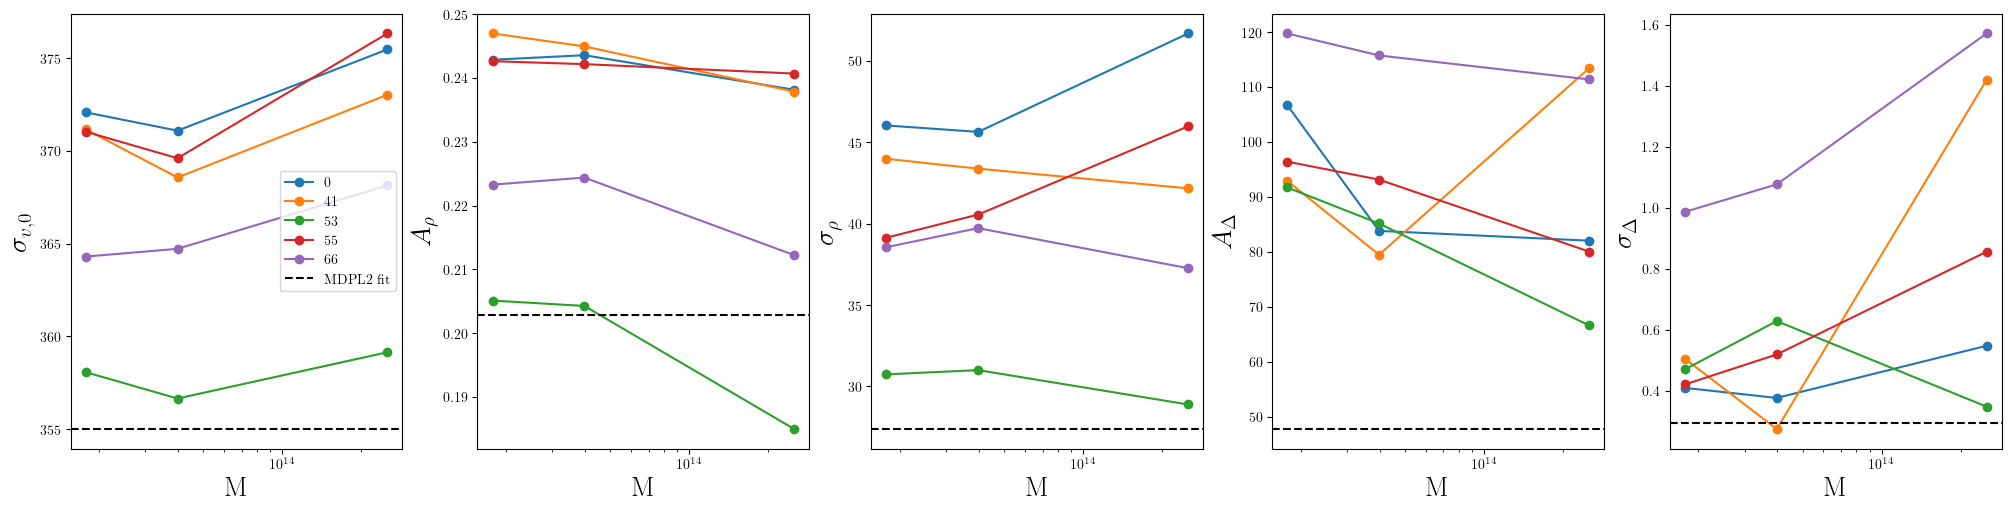

In [34]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5), layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$", r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$"]

for i, label in enumerate(labels):
    for si, sim in enumerate(cosmo_nums):

        ax[i].plot(M_cens, parameters[si, :, i], marker='o', label=f"{sim}")
    
    ax[i].axhline(fixed_parameters[i], c='k', ls='--', label='MDPL2 fit')
    
    ax[i].set_ylabel(label)
    ax[i].set_xlabel(r'M')
    ax[i].set_xscale('log')

ax[0].legend()

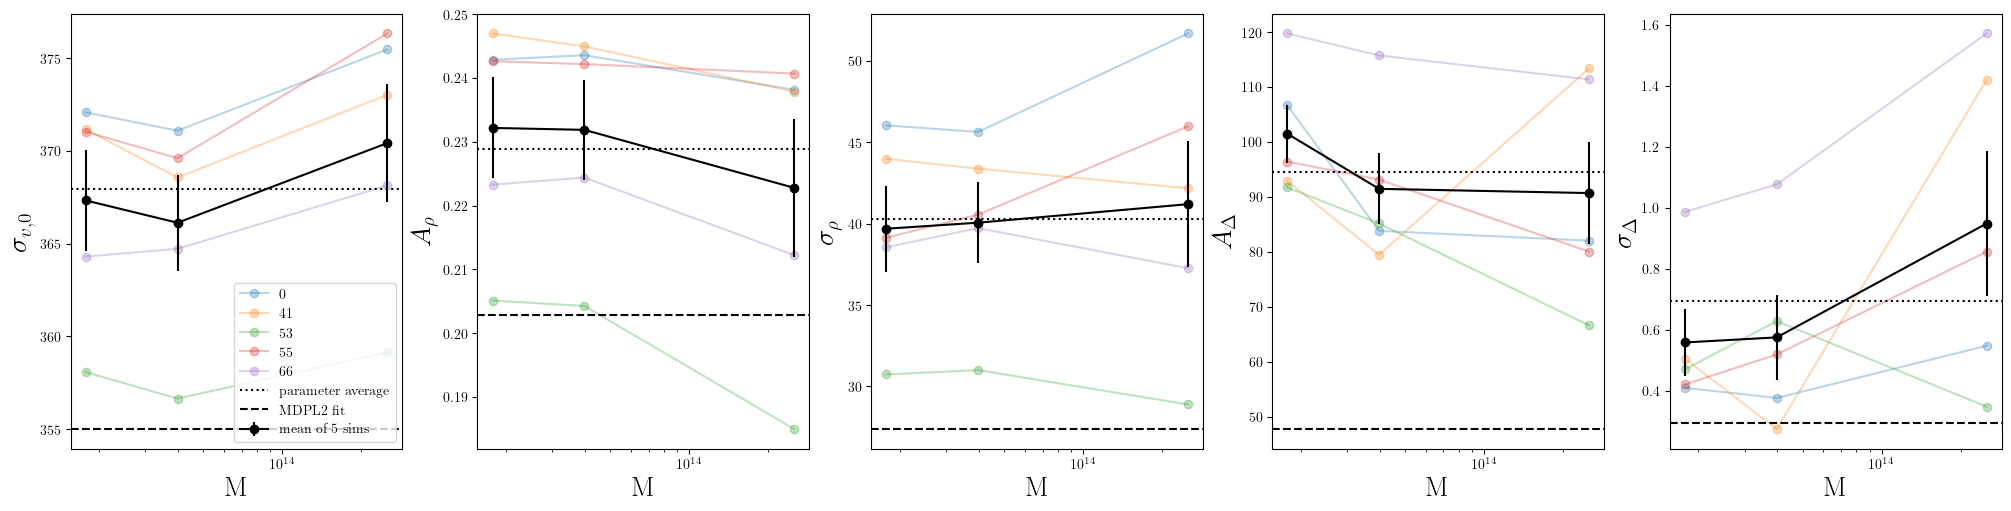

In [44]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5), layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)  # (n_sims, n_mass, n_params)

labels = [r"$\sigma_{v, 0}$", r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$"]

n_sims = parameters.shape[0]

# leave-one-out jackknife across sims, vectorized
total = parameters.sum(axis=0)                        # (n_mass, n_params)
mean_vals = total / n_sims                             # (n_mass, n_params)
loo_means = (total - parameters) / (n_sims - 1)        # (n_sims, n_mass, n_params)
jack_err = np.sqrt((n_sims - 1) / n_sims * np.sum((loo_means - mean_vals) ** 2, axis=0))

for i, label in enumerate(labels):
    for si, sim in enumerate(cosmo_nums):
        ax[i].plot(M_cens, parameters[si, :, i], marker='o', label=f"{sim}", alpha=0.3)
    ax[i].errorbar(M_cens, mean_vals[:, i], yerr=jack_err[:, i], marker='o', color='k', label='mean of 5 sims')
    ax[i].axhline(np.mean(mean_vals[:, i]), c='k', ls=':', label='parameter average')
    ax[i].axhline(fixed_parameters[i], c='k', ls='--', label='MDPL2 fit')
    ax[i].set_ylabel(label)
    ax[i].set_xlabel(r'M')
    ax[i].set_xscale('log')

ax[0].legend()

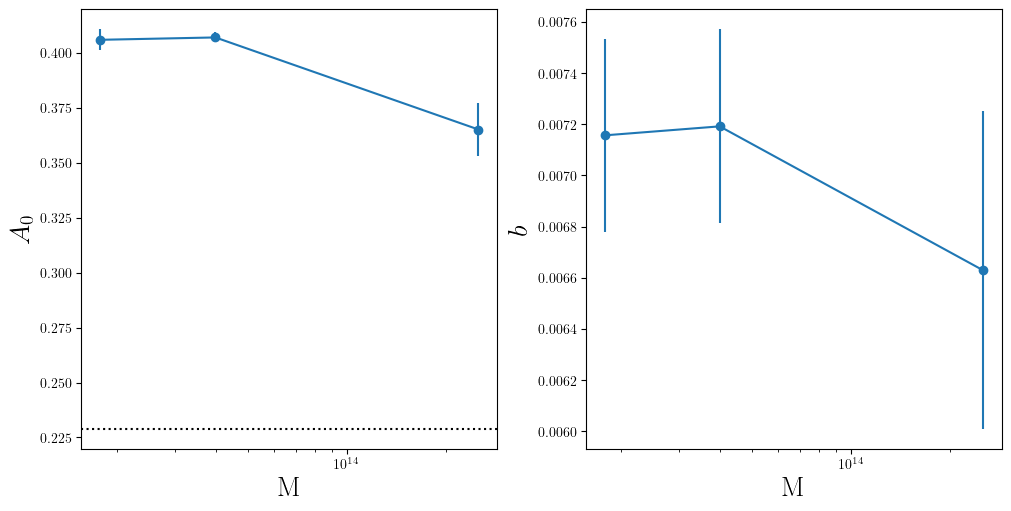

In [52]:

def exp_model(r_p, A_0, b):
    return A_0 * np.exp(-b * r_p)

n_sims, n_mass, n_rp = A_rho_R.shape

A_0_fit = np.zeros((n_sims, n_mass))
b_fit = np.zeros((n_sims, n_mass))

for si in range(n_sims):
    for mi in range(n_mass):
        y = A_rho_R[si, mi]
        p0 = [y[0], 0.1]
        popt, _ = curve_fit(exp_model, r_p[::5], y, p0=p0)
        A_0_fit[si, mi], b_fit[si, mi] = popt

# jackknife (leave-one-sim-out) over sims, vectorized, same as before
def jackknife_mean_err(x):
    # x: (n_sims, n_mass)
    total = x.sum(axis=0)
    mean_vals = total / n_sims
    loo_means = (total - x) / (n_sims - 1)
    err = np.sqrt((n_sims - 1) / n_sims * np.sum((loo_means - mean_vals) ** 2, axis=0))
    return mean_vals, err

A_0_mean, A_0_err = jackknife_mean_err(A_0_fit)
b_mean, b_err = jackknife_mean_err(b_fit)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

ax[0].errorbar(M_cens, A_0_mean, yerr=A_0_err, marker='o')
ax[0].axhline(np.mean(mean_vals[:, 1]), c='k', ls=':')
ax[0].set_ylabel(r"$A_0$")
ax[0].set_xlabel(r'M')
ax[0].set_xscale('log')

ax[1].errorbar(M_cens, b_mean, yerr=b_err, marker='o')
ax[1].set_ylabel(r"$b$")
ax[1].set_xlabel(r'M')
ax[1].set_xscale('log')

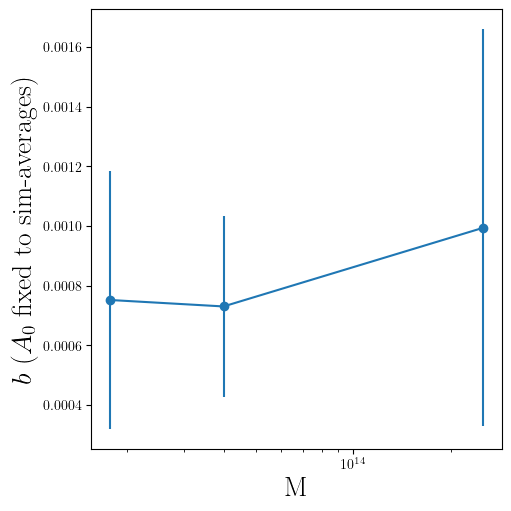

In [58]:
A_rho_M_mean = mean_vals[:, 1]  # from the first snippet, (n_mass,), A_rho averaged over sims

def exp_model_fixed_A0(r_p, b, A_0):
    return A_0 * np.exp(-b * r_p)

b_fit_fixedA0 = np.zeros((n_sims, n_mass))

for si in range(n_sims):
    for mi in range(n_mass):
        y = A_rho_R[si, mi]
        A_0 = A_rho_M_mean[mi]
        popt, _ = curve_fit(lambda r_p, b: exp_model_fixed_A0(r_p, b, A_0), r_p[::5], y, p0=[0.1])
        b_fit_fixedA0[si, mi] = popt[0]

b_fixedA0_mean, b_fixedA0_err = jackknife_mean_err(b_fit_fixedA0)

fig, ax = plt.subplots(figsize=(5, 5), layout='constrained')
ax.errorbar(M_cens, b_fixedA0_mean, yerr=b_fixedA0_err, marker='o')
ax.set_ylabel(r"$b$ ($A_0$ fixed to sim-averages)")
ax.set_xlabel(r'M')
ax.set_xscale('log')

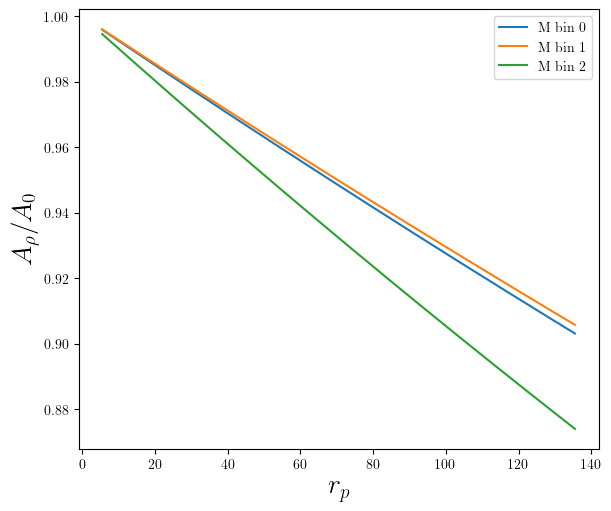

In [57]:
r_p_grid = np.linspace(r_p[::skip].min(), r_p[::skip].max(), 200)

fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

for mi in range(n_mass):
    ratio = np.exp(-b_fixedA0_mean[mi] * r_p_grid)
    ax.plot(r_p_grid, ratio, label=f"M bin {mi}")

ax.set_ylabel(r"$A_\rho / A_0$")
ax.set_xlabel(r"$r_p$")
ax.legend()

In [67]:
b_fixedA0_mean

array([0.00075198, 0.00073035, 0.00099373])